            INTERACTIVE THERMO CALCULATOR.            


Enter value of delta H in KJ/mol:  45
Enter value of delta S in KJ/(mol*K):  57


------------------------------------------------------------
Value of Enthalpy is 45.0 KJ/mol
Value of Entropy is 57.0 KJ/(mol*K)
------------------------------------------------------------
Spontaneity flip temperature (G = 0):  0.79 K
------------------------------------------------------------
At room temp 298 K
     Delta G =  -16941.00 KJ/mol
    RESULT : SPONTANEOUS (can yield upto  16941.00 KJ/mol non-mechanical work
------------------------------------------------------------

[Plot Window Opening... Close the graph view to return to terminal]


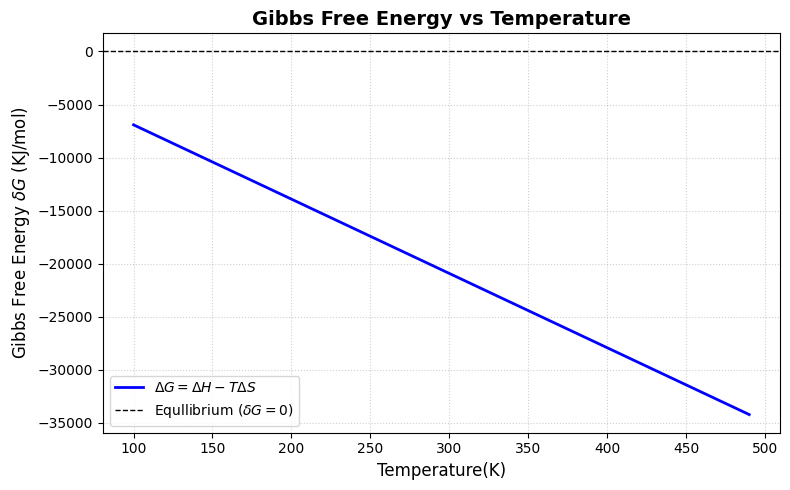

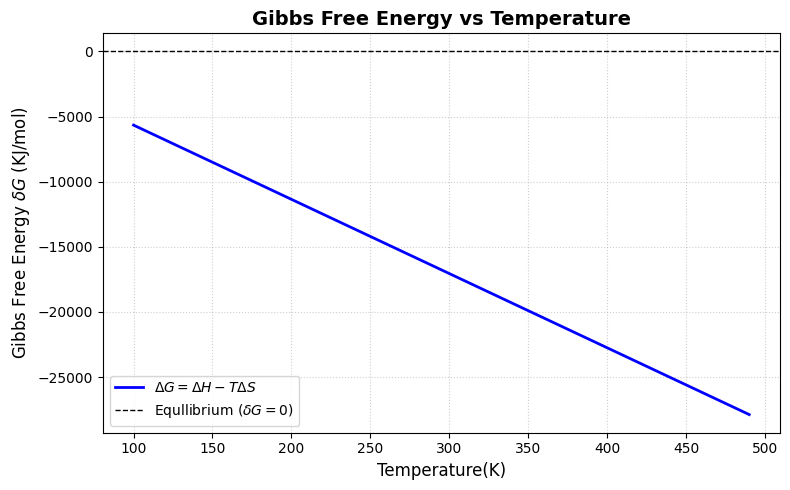

Press enter to close application... 


''

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

print('='*60)
print('            INTERACTIVE THERMO CALCULATOR.            ')
print('='*60)

#stage 1: getting inputs
delta_H_input = input('Enter value of delta H in KJ/mol: ')
delta_H = float(delta_H_input)
delta_S_input = input('Enter value of delta S in KJ/(mol*K): ')
delta_S = float(delta_S_input)

print('-'*60)
print(f'Value of Enthalpy is {delta_H} KJ/mol')
print(f'Value of Entropy is {delta_S} KJ/(mol*K)')
print('-'*60)

#stage 2 : cal spontaneity by temp flip (equillibrium)
if delta_S != 0:
    T_flip = delta_H / delta_S
    print(f'Spontaneity flip temperature (G = 0): {T_flip : .2f} K')
else:
	T_flip = None
	print('-> Delta S is zero, so temperature does not change spontaneity')
	
print('-'*60)

#stage 3: generate temp points and cal free energy
Temperatures= list(range(100, 500, 10))
delta_G_values = []

for T in Temperatures:
	dG = delta_H - (T * delta_S)
	delta_G_values.append(dG)
	
#stage 4: to check spontaneity at room temp
T_room = 298
dG_room = delta_H - (T_room * delta_S)
print(f'At room temp {T_room} K')
print(f'     Delta G =  {dG_room: .2f} KJ/mol')
if dG_room < 0:
	print(f'    RESULT : SPONTANEOUS (can yield upto {abs(dG_room): .2f} KJ/mol non-mechanical work')
else:
	print('    RESULT : NON-SPONTANEOUS (need external energy to proceed)')
	
print('-'*60)

#stage 5: plots

plt.figure(figsize=(8, 5))
plt.plot(
      Temperatures,
      delta_G_values,
      color="blue",
      linewidth=2,
      label=r'$\Delta G = \Delta H - T\Delta S$',
 )
      
plt.axhline(
      0,
      color='black',
      linestyle='--',
      linewidth=1,
      label=r'Equllibrium ($\delta G = 0$)',
 )
 
if T_flip and 100 <= T_flip <= 500:
      plt.axvline(
      T_flip, color='red', linestyle=':', label=f'Flip point ({T_flip: .2f} K)'
      )
plt.title('Gibbs Free Energy vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature(K)', fontsize=12)
plt.ylabel('Gibbs Free Energy $\delta G$ (KJ/mol)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6) 
plt.legend(fontsize=10) 
plt.tight_layout()

print("\n[Plot Window Opening... Close the graph view to return to terminal]")
plt.show()

print('='*60)
input('Press enter to close application...')